In [1]:
#ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('task1_dataset.csv')
df.head()

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,2020-01-01,63,63013.191704,279389.811431,616.029633,31,6.904324e+05,Bangalore,Unemployed,Auto,294319.227774
1,2020-01-02,20,47161.859481,950897.454063,716.561294,33,5.951086e+05,Bangalore,Student,Home,154516.648673
2,2020-01-03,46,55234.345094,NaN,564.991196,28,9.989912e+05,Delhi,Student,Auto,252354.507062
3,2020-01-04,52,74712.765160,431159.014692,572.736033,25,7.007800e+05,Chennai,Unemployed,Home,226719.203929
4,2020-01-05,56,82830.588108,272730.054365,813.630055,34,1.105784e+06,Delhi,Unemployed,Home,225838.346929


In [4]:
df.isnull().sum()

date                 0
age                  0
income              80
loan_amount         80
credit_score        80
num_transactions     0
annual_spend        80
city                 0
employment_type      0
loan_type            0
target               0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              2000 non-null   object 
 1   age               2000 non-null   int64  
 2   income            1920 non-null   float64
 3   loan_amount       1920 non-null   float64
 4   credit_score      1920 non-null   float64
 5   num_transactions  2000 non-null   int64  
 6   annual_spend      1920 non-null   float64
 7   city              2000 non-null   object 
 8   employment_type   2000 non-null   object 
 9   loan_type         2000 non-null   object 
 10  target            2000 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 172.0+ KB


In [6]:
df.describe()

,age,income,loan_amount,credit_score,num_transactions,annual_spend,target
count,2000.000000,1920.000000,1.920000e+03,1920.000000,2000.00000,1.920000e+03,2000.000000
mean,43.569500,64111.180976,3.135794e+05,649.451886,30.13600,1.081605e+06,246455.466965
std,14.892786,35334.616365,1.415505e+05,80.483534,5.24006,7.028877e+05,66306.121409
min,18.000000,-5135.359342,-2.336766e+04,373.096400,14.00000,-1.461650e+05,13300.170171
25%,31.000000,46943.316170,2.337310e+05,594.475126,27.00000,7.887255e+05,201830.604797
50%,43.000000,60602.715999,3.041103e+05,649.578439,30.00000,1.004297e+06,245424.498558
75%,56.000000,75294.080356,3.722464e+05,703.239833,33.00000,1.214651e+06,292110.550126
max,69.000000,426093.266439,1.525158e+06,919.903709,52.00000,7.541094e+06,478502.472525


In [7]:
df.isnull().sum()

date                 0
age                  0
income              80
loan_amount         80
credit_score        80
num_transactions     0
annual_spend        80
city                 0
employment_type      0
loan_type            0
target               0
dtype: int64

In [8]:
df['date'] = pd.to_datetime(df['date'])

# create new columns
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

In [9]:
# handled  missing value with median value
df["income"].fillna(df["income"].median(), inplace=True)
df["credit_score"].fillna(df["credit_score"].median(), inplace=True)
df["loan_amount"].fillna(df["loan_amount"].median(), inplace=True)
df["annual_spend"].fillna(df["annual_spend"].median(), inplace=True)

In [10]:
df.isnull().sum()

date                0
age                 0
income              0
loan_amount         0
credit_score        0
num_transactions    0
annual_spend        0
city                0
employment_type     0
loan_type           0
target              0
day                 0
month               0
year                0
dtype: int64

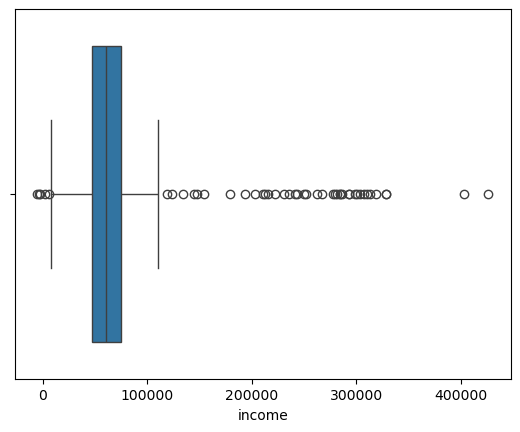

In [11]:
sns.boxplot(x=df["income"])
plt.show()

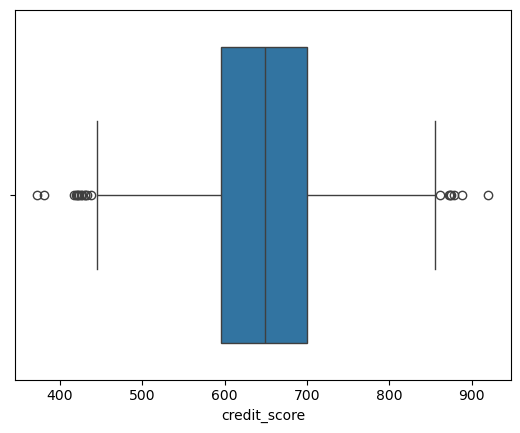

In [12]:
sns.boxplot(x=df["credit_score"])
plt.show()

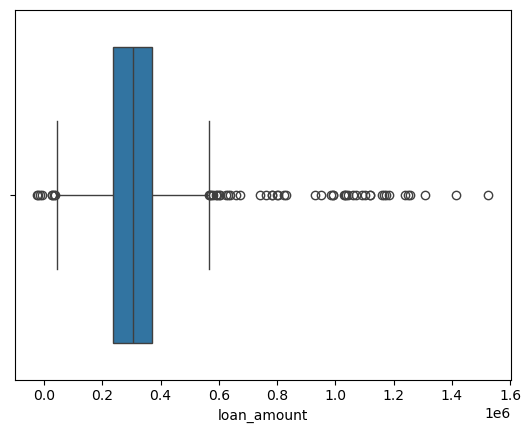

In [13]:
sns.boxplot(x=df["loan_amount"])
plt.show()

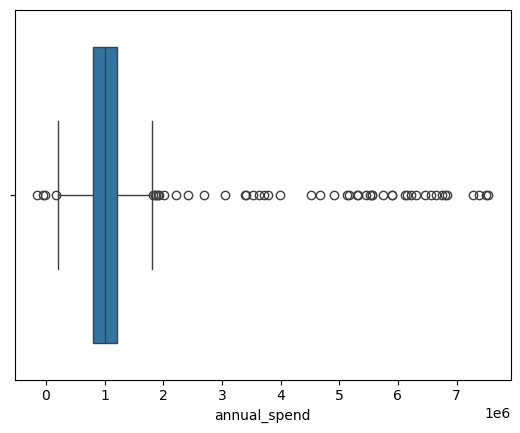

In [14]:
sns.boxplot(x=df["annual_spend"])
plt.show()

In [15]:
# use clip method to handle outliers in the "income" column
def cap_outlier(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

In [16]:
#  use the function to cap outliers in the "income","loan_amount" and "credit_score" columns
cap_outlier("income")
cap_outlier("loan_amount")
cap_outlier("credit_score")
cap_outlier("annual_spend")
cap_outlier("num_transactions")

In [17]:
df.isnull().sum()

date                0
age                 0
income              0
loan_amount         0
credit_score        0
num_transactions    0
annual_spend        0
city                0
employment_type     0
loan_type           0
target              0
day                 0
month               0
year                0
dtype: int64

In [18]:
# handled the categorical variable with one hot encoding using sklearn library
cat=['city','employment_type','loan_type']
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoded_data=encoder.fit_transform(df[cat])

In [19]:
#encoded data convereted into dataframe
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(cat))
encoded_df

,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,loan_type_Auto,loan_type_Education,loan_type_Home,loan_type_Personal
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1996,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1997,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1998,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [20]:
df=pd.concat([df.drop(columns=cat),encoded_df],axis=1)

In [21]:
df.head()

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,target,day,month,...,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,loan_type_Auto,loan_type_Education,loan_type_Home,loan_type_Personal
0,2020-01-01,63,63013.191704,279389.811431,616.029633,31,6.904324e+05,294319.227774,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,2020-01-02,20,47161.859481,564973.609203,716.561294,33,5.951086e+05,154516.648673,2,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2020-01-03,46,55234.345094,304110.307297,564.991196,28,9.989912e+05,252354.507062,3,1,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,2020-01-04,52,74712.765160,431159.014692,572.736033,25,7.007800e+05,226719.203929,4,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,2020-01-05,56,82830.588108,272730.054365,813.630055,34,1.105784e+06,225838.346929,5,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [22]:
df.drop('date', axis=1, inplace=True)

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib

In [28]:
df = pd.get_dummies(df, drop_first=True)

In [29]:
X = df.drop("target", axis=1)
y = df["target"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF R2:", r2_score(y_test, rf_pred))

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print("RF RMSE:", rf_rmse)

RF R2: 0.39525026856713164
RF RMSE: 52245.23945953352


In [34]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [36]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
train_pred = xgb.predict(X_train)

from sklearn.metrics import r2_score
print("Training R2:", r2_score(y_train, train_pred))

Training R2: 0.8999409097082886


In [39]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

from sklearn.metrics import r2_score
print("Final Test R2:", r2_score(y_test, xgb_pred))

Final Test R2: 0.3986560434850357
